## Read XTCAV TREXB data and compare with live model

In [1]:
import numpy as np
import os

import h5py

from skimage.filters import sobel
from skimage.util import img_as_ubyte
from skimage.segmentation import watershed
from skimage.filters.rank import median
from skimage.morphology import disk
from pmd_beamphysics.units import mec2, c_light
import scipy.ndimage as ndimage

import matplotlib.pyplot as plt
import epics
import scipy

## Read matlab data

In [2]:
import scipy.io
data_filename = 'XTCAV_data/TREXB-Sample-2025-04-05-125158.mat'
final_beam = 'XTCAV_data/sim/LCLSII-snapshot-2025-04-05T12:53:22-07:00.h5'

In [6]:
f = h5py.File(data_filename, 'r')

In [11]:
print(f['#refs#']['a'].keys())

AttributeError: 'Dataset' object has no attribute 'keys'

In [8]:
print(f['data'].keys())
curr = np.array(f['data']['curr'])


time_axis_fs = np.array(f['data']['time_axis_fs'])
erg_axis_MeV = np.array(f['data']['erg_axis_MeV'])
imag = np.array(f['data']['img'])
sli_erg_spread = np.array(f['data']['sli_erg_spread'])
erg_cen = np.array(f['data']['erg_cen'])
time_start = np.array(f['data']['time_start'])


<KeysViewHDF5 ['bgr', 'bgr_orig', 'charge', 'colors', 'curr', 'curr1', 'curr2', 'cut_level', 'dispersion', 'eduration_fwhm', 'erg_axis_MeV', 'erg_cen', 'erg_corr', 'img', 'img_orig', 'init_streak', 'mean_erg', 'num_slices', 'px2um', 'sli_erg_spread', 'sli_width', 'streak', 'sync', 'time_axis_fs', 'time_cen', 'time_cen_sli', 'time_start', 'xray']>
<HDF5 dataset "time_axis_fs": shape (590, 1), type "<f8">


/lscratch/jytang/tmp/ipykernel_1381503/2436278206.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  curr = np.array(f['data']['curr'])
/lscratch/jytang/tmp/ipykernel_1381503/2436278206.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  time_axis_fs = np.array(f['data']['time_axis_fs'])
/lscratch/jytang/tmp/ipykernel_1381503/2436278206.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  erg_axis_MeV = np.array(f['data']['erg_axis_MeV'])
/lscratch/jytang/tmp/ipykernel_1381503/2436278206.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must imple

In [9]:
print(f['data']['time_axis_fs'])

<HDF5 dataset "time_axis_fs": shape (590, 1), type "<f8">


In [5]:
f.close()

In [7]:
imag_t = np.flip(imag).T
print(imag.shape)
print(time_axis_fs.shape)
print(erg_axis_MeV.shape)

(590, 224)
(590, 1)
(224, 1)


Text(0, 0.5, '$\\Delta E (MeV)$')

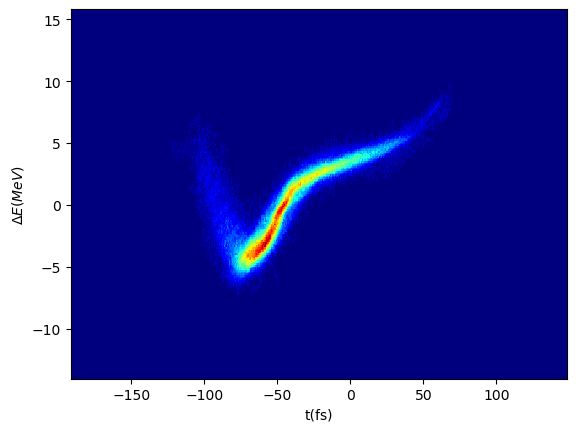

In [8]:
plt.imshow(imag_t, extent =(time_axis_fs.min(), time_axis_fs.max(), erg_axis_MeV.min(), erg_axis_MeV.max()), aspect = 'auto', cmap = 'jet', interpolation = 'none', origin = 'lower')
plt.xlabel('t(fs)')
plt.ylabel(r'$\Delta E (MeV)$')

Text(0, 0.5, 'current (kA)')

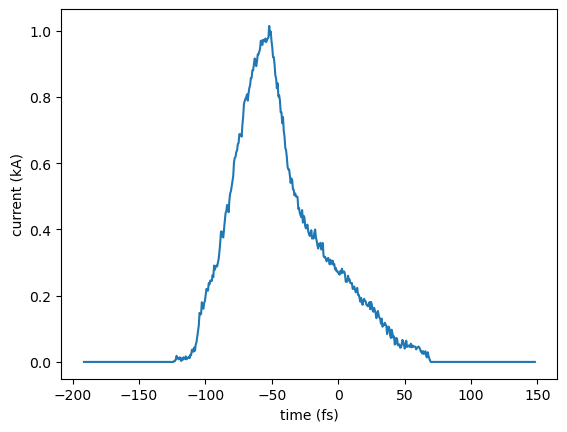

In [9]:
temp = np.sum(imag_t, axis = 0)
max_curr = np.max(curr)
temp /= np.max(temp)
current = temp*max_curr
plt.plot(time_axis_fs, current)
plt.xlabel('time (fs)')
plt.ylabel('current (kA)')

In [10]:
energy_center = np.sum(erg_axis_MeV*imag.T, axis = 0)/np.sum(imag.T, axis = 0)

/lscratch/jytang/tmp/ipykernel_1286234/1156246662.py:1: RuntimeWarning: invalid value encountered in divide
  energy_center = np.sum(erg_axis_MeV*imag.T, axis = 0)/np.sum(imag.T, axis = 0)


Text(0, 0.5, 'centroid energy deviation (MeV)')

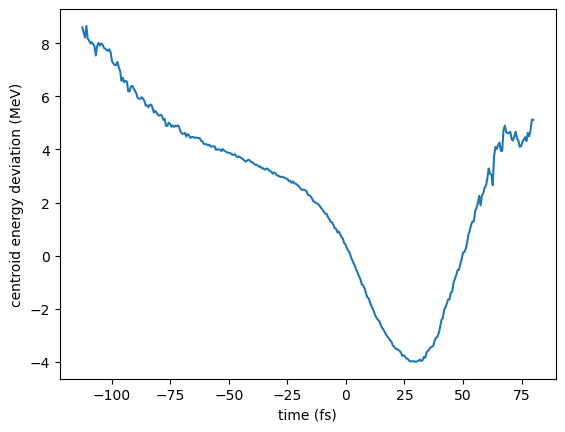

In [11]:
plt.plot(time_axis_fs, energy_center)
plt.xlabel('time (fs)')
plt.ylabel('centroid energy deviation (MeV)')

## Load beam from live mode

In [12]:
from pmd_beamphysics import ParticleGroup



In [13]:
P = ParticleGroup(final_beam)

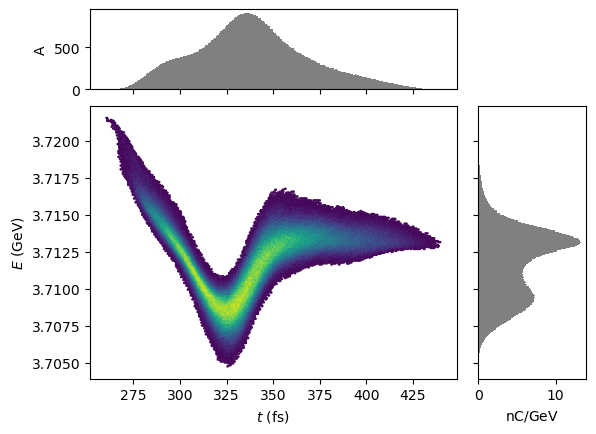

In [14]:
P.plot('t', 'energy')

In [16]:
?P.slice_statistics

Signature: P.slice_statistics(*keys, n_slice=100, slice_key=None)
Docstring: Slice statistics
File:      ~/miniconda3/envs/lume-eblt-dev/lib/python3.12/site-packages/pmd_beamphysics/particles.py
Type:      method

In [17]:
ss = P.slice_statistics( "mean_energy", n_slice = 200)
ss.keys()

dict_keys(['mean_t', 'charge', 'ptp_t', 'mean_energy', 'current'])

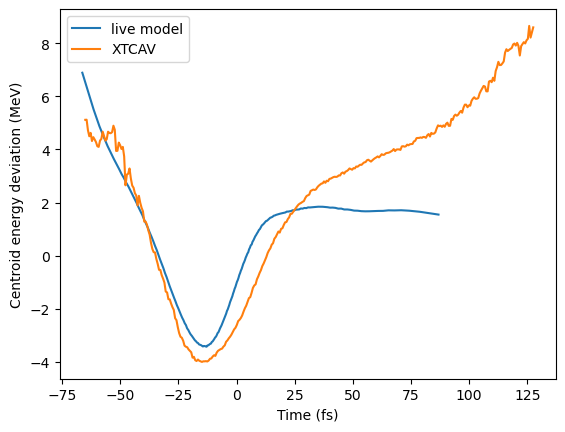

In [18]:
plt.plot((ss['mean_t'] - np.mean(ss['mean_t']))*1e15, (ss['mean_energy'] - np.mean(ss['mean_energy']))/1e6, label = 'live model')
plt.plot(-time_axis_fs+15 , energy_center, label = 'XTCAV')
plt.xlabel('Time (fs)')
plt.ylabel('Centroid energy deviation (MeV)')
plt.legend()

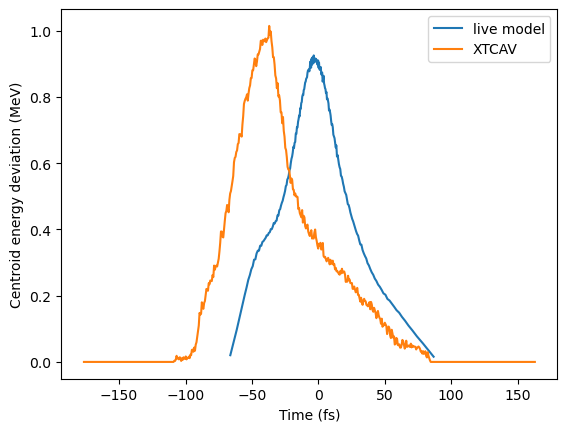

In [19]:
plt.plot((ss['mean_t'] - np.mean(ss['mean_t']))*1e15,ss['current']/1e3, label = 'live model')
plt.plot(time_axis_fs+15 , current, label = 'XTCAV')
plt.xlabel('Time (fs)')
plt.ylabel('Centroid energy deviation (MeV)')
plt.legend()